# Module Imports 

### Note that project root path should be in your OS path so that you can access other modules in your project while in this jupyter notebook

In [10]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import models.classification as classify
import models.loops as loops
import models.models as models
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
)

import io
import contextlib

# Loading and Preparing Data

## Phase 1

### I have used pandas here to prepare a table like dataframe to store the data.
df_X is the dataframe for audio samples \
df_X is the dataframe for audio labels

In [11]:
# load & preprocess
P1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
P1_samples = pd.DataFrame(P1_data['x'].T)
P1_labels  = pd.DataFrame(P1_data['y'].T, columns=['y'])
P1_df = pd.concat([P1_samples, P1_labels], axis=1).dropna().sample(frac=1, random_state=42)
shuffled_df = P1_df.sample(frac=1, random_state=42).reset_index(drop=True)
P1_df_X = shuffled_df.iloc[:, :-1]
P1_df_Y = shuffled_df.iloc[:, -1]


### Data can be extracted using Extract_Features
**Use Extract_Features object from ../data_classes/decomposition.py**

**Use "feature" argument in Extract_Features to choose which feature extraction method you want or add your own if you want.**

**By default Extract_Features returns a Pytorch dataset to be used for pytorch train/test/val loops**

In [12]:
## Look into Extract_Features class in ../data_classes/decomposition.py for available feature extraction methods.

## This is how you get raw audio data as a Pytorch dataset
P1_raw = Extract_Features(P1_df_X, P1_df_Y, feature='raw')

In [13]:
## This is how you can extract fetaures in the form of numpy arrays
print(P1_raw.get_samples().shape, P1_raw.get_labels().shape)

(3309, 36000) (3309,)


### Data Distribution 

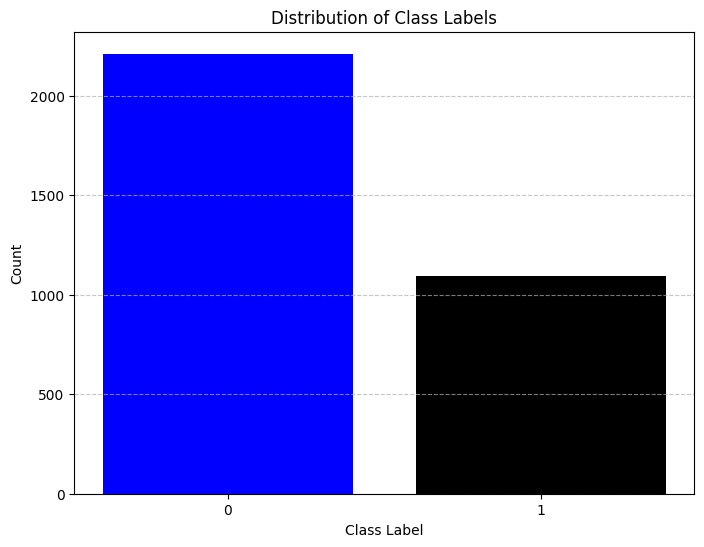

In [14]:
# Show label distribution
label_counts = P1_df_Y.value_counts()
plt.figure(figsize=(8, 6))
# use blue and black color for the 0 and 1 classes respectively

colors = ['blue' if x == 0 else 'black' for x in label_counts.index]
plt.bar(label_counts.index.astype(int), label_counts.values, color=colors)
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title('Distribution of Class Labels')
plt.xticks(label_counts.index.astype(int))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Phase 1 Waveform Overlay

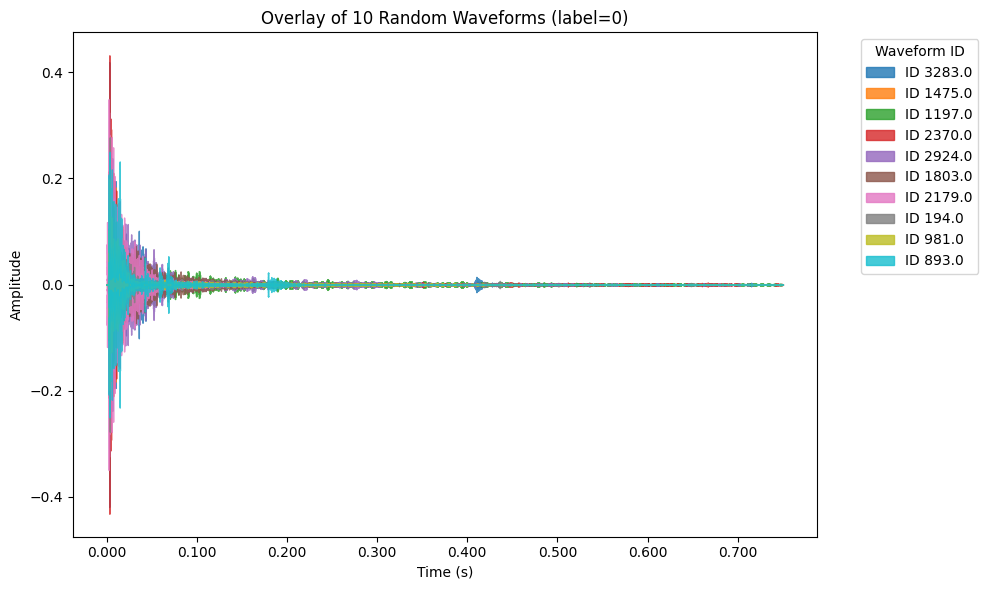

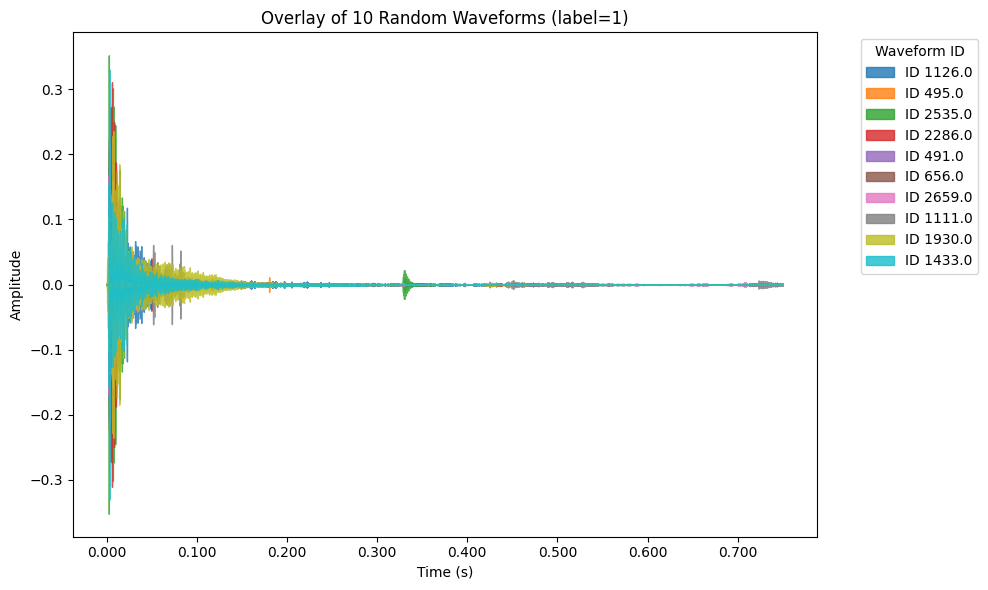

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import librosa.display

P1_sr = 48000
samples = P1_df[P1_df['y'] == 0].sample(10).reset_index(drop=False)

plt.figure(figsize=(10, 6))

# More contrastive colors for 10 distinct waveforms
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']
    example = row.drop(['index', 'y']).values.astype(float)

    librosa.display.waveshow(
        example,
        sr=P1_sr,
        alpha=0.8,
        color=color,
        label=f'ID {wave_id}'
    )

plt.title('Overlay of 10 Random Waveforms (label=0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

samples = P1_df[P1_df['y'] == 1].sample(10).reset_index(drop=False)

plt.figure(figsize=(10, 6))

# More contrastive colors for 10 distinct waveforms
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']
    example = row.drop(['index', 'y']).values.astype(float)

    librosa.display.waveshow(
        example,
        sr=P1_sr,
        alpha=0.8,
        color=color,
        label=f'ID {wave_id}'
    )

plt.title('Overlay of 10 Random Waveforms (label=1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### PCA Analysis to compare with previous research paper

**PCA feature in extract features lets you choose either explained_variance or number of components you want.**

Use parameter "explained_variance" or "n_components"

In [8]:
P1_PCA = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=0.95)

In [9]:
print("Number of components explaining 95% variance:", P1_PCA.get_samples().shape[1])
print(P1_PCA.get_samples().shape, P1_PCA.get_labels().shape)


Number of components explaining 95% variance: 396
(3309, 396) (3309,)


**However to compare performance on different combinations of extracted features and type of classification model used we need to create more pca objects**

In [26]:
# === PCA EV sweep with fixed nb_hidden {256,128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)

explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [256, 128, 64, 32]   # fixed hidden sizes
batch_size = 32
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P1_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx_all, test_size=0.2,random_state=42, stratify=y_all
)

results = []

device_str = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    # PCA features via Extract_Features
    P1_PCA = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P1_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds, test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P1_PCA.get_samples()
    y = P1_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    # SVM baseline
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))

    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc * 100,   # store as percentage number
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    # Only MLP 2-layer and 3-layer
    for h in hidden_grid:


        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP", "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P1.pth")

            # Train
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                loops.train(
                    model=model,
                    model_path=model_path,
                    train_loader=train_loader,
                    val=False,
                    val_loader=None,
                    batch_size=batch_size,
                    lr=1e-3,
                    weight_decay=0,
                    optim="adam",
                    epochs=epochs,
                )


            # Test
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                test_results = loops.test(
                    model=model,
                    model_path=model_path,
                    test_loader=test_loader,
                    report=False,
                    score=True,
                    device=device_str
                )

            acc = test_results["accuracy"]

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc * 100,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })
    print(f"Finished explained variance = {int(ev * 100)}")

# ---- Results & Plot ----
df_res = (
    pd.DataFrame(results)
    .sort_values(["explained_variance", "model", "nb_hidden"])
    .reset_index(drop=True)
)

# ---- Figure dataframe (exclude MLP 1-layer only from plot) ----
df_plot = df_res[df_res["model"] != "MLP (1-layer)"].copy()

fig = px.line(
    df_plot,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes: 256, 128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy (%)",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.2f"}
)

fig.update_layout(
    hovermode="x unified",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        automargin=True,
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        ticks="outside",
        ticklen=6,
        tickwidth=1,
        tickcolor="black"
    ),
    yaxis=dict(
        automargin=True,
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        mirror=True,
        ticks="outside",
        ticklen=6,
        tickwidth=1,
        tickcolor="black"
    )
)

# ---- Save figure ----
save_dir = "../assets/march_paper"
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(save_dir, "pca_ev_sweep_accuracy.png")
html_path = os.path.join(save_dir, "pca_ev_sweep_accuracy.html")

fig.write_html(html_path)
fig.write_image(png_path, width=1400, height=800, scale=2)

print(f"Saved interactive figure to: {html_path}")
print(f"Saved static figure to: {png_path}")

fig.show()

pd.set_option("display.max_rows", None)
display(df_res)

Finished explained variance = 80
Finished explained variance = 85
Finished explained variance = 90
Finished explained variance = 95
Finished explained variance = 96
Finished explained variance = 97
Finished explained variance = 98
Finished explained variance = 99
Saved interactive figure to: ../assets/march_paper/pca_ev_sweep_accuracy.html
Saved static figure to: ../assets/march_paper/pca_ev_sweep_accuracy.png


,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,81.419940,87,H=[128]
1,80,MLP (1-layer),256,80.513595,87,H=[256]
2,80,MLP (1-layer),32,79.456193,87,H=[32]
3,80,MLP (1-layer),64,80.815710,87,H=[64]
4,80,MLP (2-layer),128,84.592145,87,"H=[128, 64]"
5,80,MLP (2-layer),256,83.836858,87,"H=[256, 128]"
6,80,MLP (2-layer),32,81.873112,87,"H=[32, 16]"
7,80,MLP (2-layer),64,81.419940,87,"H=[64, 32]"
8,80,MLP (3-layer),128,83.836858,87,"H=[128, 64, 32]"
9,80,MLP (3-layer),256,85.045317,87,"H=[256, 128, 64]"


### ROC Dataframe initialization


In [15]:

roc_df = pd.DataFrame(columns=[
    "model_name",
    "model",
    "ev_pct",
    "hidden",
    "accuracy",
    "roc_auc",
    "fpr",
    "tpr",
    "roc_thresholds",
])

roc_df

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds


### Best Combination PCA + MLP

[RETRAIN] EV=90%, model=MLP (2-layer), nb_hidden=256
[RETRAIN] Saving checkpoint to -> ./final_model_paths/mlp2_ev90_h256_P1_RETRAIN.pth
[RETRAIN] model_name key -> mlp2_ev90_h256_P1_RETRAIN
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.8535


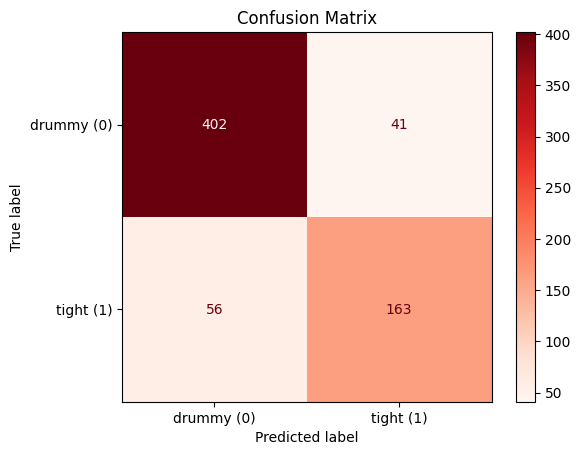

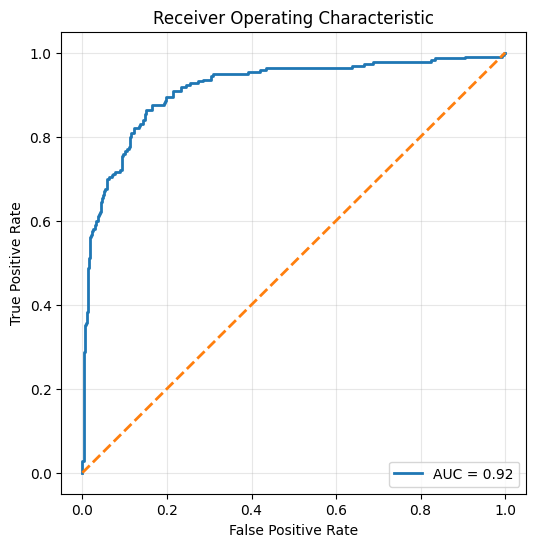


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

  drummy (0)       0.88      0.91      0.89       443
   tight (1)       0.80      0.74      0.77       219

    accuracy                           0.85       662
   macro avg       0.84      0.83      0.83       662
weighted avg       0.85      0.85      0.85       662

[RETRAIN] Accuracy: 0.8535
[RETRAIN] ROC AUC: 0.9157


/var/folders/nh/9fsl45m17nn6q_xt_zd0wwbw0000gn/T/ipykernel_18624/2041715504.py:133: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  roc_df = pd.concat([roc_df, new_row], ignore_index=True)


[GRAPH] Saved to: ../assets/march_paper/best_model_mlp2_ev90_h256_P1_RETRAIN.png (and/or .pdf)


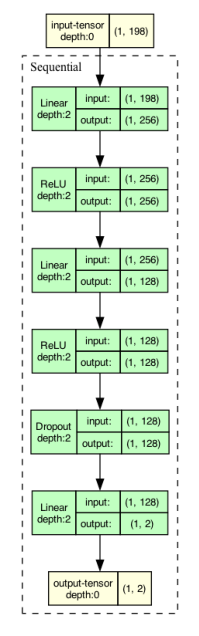

In [16]:
# === Retrain + Test using the hard-coded best combo, then draw graph ===
torch.manual_seed(42)
np.random.seed(42)

# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 90
BEST_MODEL_NAME = "MLP (2-layer)"   # "MLP (1-layer)" | "MLP (2-layer)" | "MLP (3-layer)"
BEST_HIDDEN     = 256               # 256 | 128 | 64 | 32
# -----------------------------------------------------

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Recreate mappings
pretty_to_ctor = {
    "MLP (1-layer)": "MLP",
    "MLP (2-layer)": "MLP_2_layer",
    "MLP (3-layer)": "MLP_3_layer",
}
ctor_to_tag = {"MLP": "mlp1", "MLP_2_layer": "mlp2", "MLP_3_layer": "mlp3"}

ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag = ctor_to_tag[ctor_name]

# Unique model id used as key in roc_df
model_name = f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P1_RETRAIN"

# Output dirs/paths
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, f"{model_name}.pth")

print(f"[RETRAIN] EV={BEST_EV_PCT}%, model={BEST_MODEL_NAME}, nb_hidden={BEST_HIDDEN}")
print(f"[RETRAIN] Saving checkpoint to -> {model_path}")
print(f"[RETRAIN] model_name key -> {model_name}")

# --- PCA dataset for the chosen EV
best_ev = BEST_EV_PCT / 100.0
P1_PCA_best = Extract_Features(
    P1_df_X,
    P1_df_Y,
    feature="pca",
    explained_variance=best_ev
)

# Split (same seed/stratify as before)
y_all = P1_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# Torch loaders
full_ds = P1_PCA_best
train_ds = Subset(full_ds, train_idx.tolist())
test_ds = Subset(full_ds, test_idx.tolist())

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

# Infer dims
X_best = P1_PCA_best.get_samples()
input_dim = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)

# Instantiate the winning architecture from models/classification.py
common_kwargs = {
    "nb_hidden": int(BEST_HIDDEN),
    "input_dim": int(input_dim),
    "output_dim": int(num_classes),
    "dropout_rate": 0.2,
}
model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- TRAIN -----------------
epochs = 20

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=0,
        optim="adam",
        epochs=epochs,
    )

# ----------------- TEST -----------------

test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
    device=device_str
)

acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]

print(f"[RETRAIN] Accuracy: {acc:.4f}")
print(f"[RETRAIN] ROC AUC: {roc_auc:.4f}")

# ----------------- UPSERT ROC VALUES INTO DATAFRAME -----------------
new_row = pd.DataFrame([{
    "model_name": model_name,                 # unique key
    "model": BEST_MODEL_NAME,                # pretty display name
    "ev_pct": BEST_EV_PCT,
    "hidden": BEST_HIDDEN,
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
}])

# remove old row with same unique key, then append new one
roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)


# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/march_paper/best_model_{model_name}"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device="cpu",
    save_graph=True,
    filename=graph_fname,
)
print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")

# show graph in notebook
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
img_path = f"{graph_fname}.png"
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print(f"Graph image not found at {img_path}")

In [7]:
# Save ROC values in a dataframe for one final graph for comparison over all models
roc_df.head()

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds
0,mlp2_ev90_h256_P1_RETRAIN,MLP (2-layer),90,256,0.853474,0.915736,"[0.0, 0.0, 0.0, 0.004514672686230248, 0.004514...","[0.0, 0.0045662100456621, 0.0273972602739726, ...","[inf, 0.9966568, 0.9921319, 0.98960984, 0.9395..."


### PCA => EV(90%) + SVM for classification

Accuracy: 0.8263


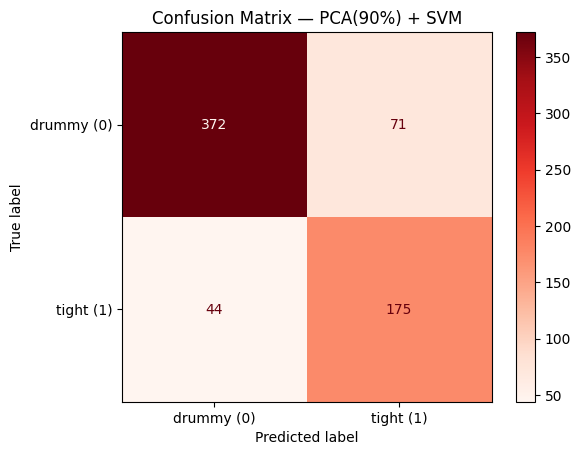


Classification Report:

              precision    recall  f1-score   support

  drummy (0)       0.89      0.84      0.87       443
   tight (1)       0.71      0.80      0.75       219

    accuracy                           0.83       662
   macro avg       0.80      0.82      0.81       662
weighted avg       0.83      0.83      0.83       662

ROC AUC: 0.8813


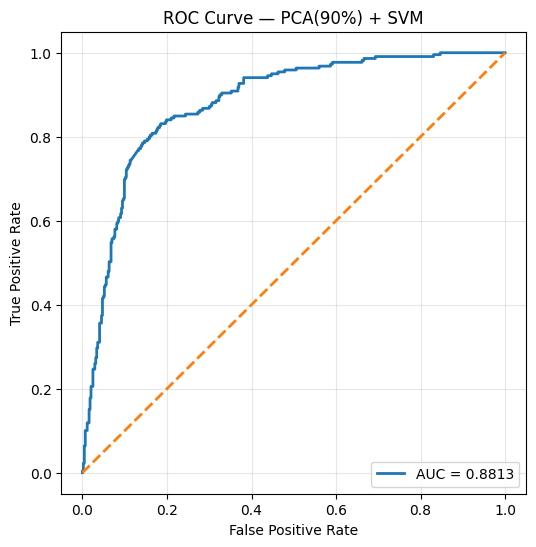

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds
0,mlp2_ev90_h256_P1_RETRAIN,MLP (2-layer),90,256,0.853474,0.915736,"[0.0, 0.0, 0.0, 0.004514672686230248, 0.004514...","[0.0, 0.0045662100456621, 0.0273972602739726, ...","[inf, 0.9966568, 0.9921319, 0.98960984, 0.9395..."
1,svm_rbf_pca_ev90,SVM (RBF),90,—,0.826284,0.881346,"[0.0, 0.0, 0.002257336343115124, 0.00225733634...","[0.0, 0.0045662100456621, 0.0045662100456621, ...","[inf, 0.9787043639894185, 0.9647695390493778, ..."


In [17]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

np.random.seed(42)
# -----------------------------
# Data
# -----------------------------
X = P1_df_X.to_numpy()
y = P1_df_Y.squeeze().astype(int).to_numpy() if hasattr(P1_df_Y, "to_numpy") else P1_df_Y.squeeze().astype(int).values

idx_all = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# flatten if needed
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

EV_PCT = 90

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=EV_PCT / 100.0, random_state=42)),
    ("svm", SVC(
        kernel="rbf",
        C=100,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svm_pipe.fit(X_train_2d, y_train)

y_pred = svm_pipe.predict(X_test_2d)
y_score = svm_pipe.predict_proba(X_test_2d)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["drummy (0)", "tight (1)"]
)
disp.plot(cmap="Reds", values_format=".0f")
plt.title(f"Confusion Matrix — PCA({EV_PCT}%) + SVM")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

report = classification_report(
    y_test,
    y_pred,
    target_names=["drummy (0)", "tight (1)"],
    zero_division=0
)
print("\nClassification Report:\n")
print(report)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — PCA({EV_PCT}%) + SVM")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

roc_values_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "roc_threshold": roc_thresholds
})

model_name = f"svm_rbf_pca_ev{EV_PCT}"

new_row = pd.DataFrame([{
    "model_name": model_name,
    "model": "SVM (RBF)",
    "ev_pct": EV_PCT,
    "hidden": "—",
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
}])

if "roc_df" not in globals():
    roc_df = pd.DataFrame(columns=[
        "model_name",
        "model",
        "ev_pct",
        "hidden",
        "accuracy",
        "roc_auc",
        "fpr",
        "tpr",
        "roc_thresholds",
    ])

roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)

display(roc_df)

### Convolution (ResNet End-to-End)

##### Train vs Validation to find the best epoch to train

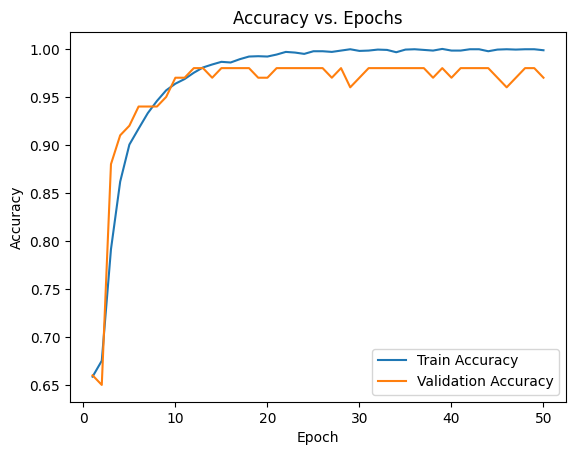

In [14]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 2900))
val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(P1_raw, train_idx)
val_data = torch.utils.data.Subset(P1_raw, val_idx)
test_data = torch.utils.data.Subset(P1_raw, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 50

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    history = loops.train(model=model, model_path="./final_model_paths/convolution_p1.pth", train_loader=train_loader,val=True, val_loader = val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.test(model=model,model_path="./final_model_paths/convolution_p1.pth", test_loader=test_loader)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##### Test routine

[INFO] Testing the model
Test accuracy (threshold=0.50): 0.9709


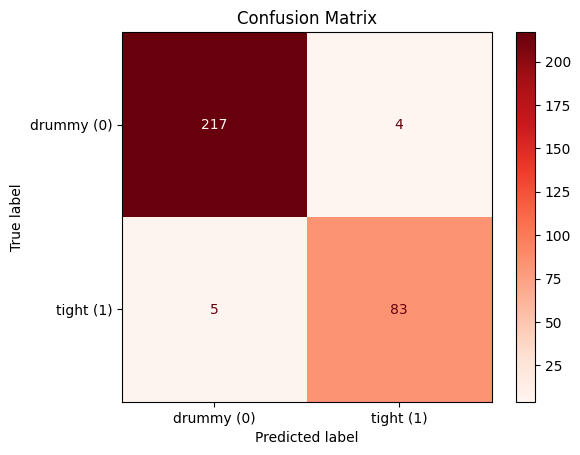

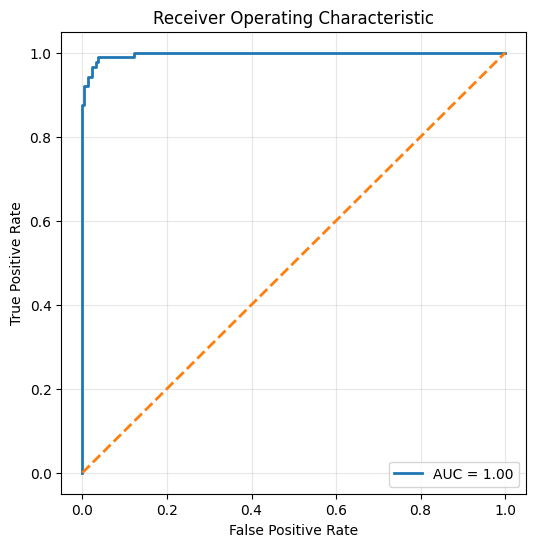


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

  drummy (0)       0.98      0.98      0.98       221
   tight (1)       0.95      0.94      0.95        88

    accuracy                           0.97       309
   macro avg       0.97      0.96      0.96       309
weighted avg       0.97      0.97      0.97       309



,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds
0,mlp2_ev90_h256_P1_RETRAIN,MLP (2-layer),90,256,0.853474,0.915736,"[0.0, 0.0, 0.0, 0.004514672686230248, 0.004514...","[0.0, 0.0045662100456621, 0.0273972602739726, ...","[inf, 0.9966568, 0.9921319, 0.98960984, 0.9395..."
1,svm_rbf_pca_ev90,SVM (RBF),90,—,0.826284,0.881346,"[0.0, 0.0, 0.002257336343115124, 0.00225733634...","[0.0, 0.0045662100456621, 0.0045662100456621, ...","[inf, 0.9787043639894185, 0.9647695390493778, ..."
2,resnet_mlp_p1,ResNet_MLP_P1,NaN,NaN,0.970874,0.996812,"[0.0, 0.0, 0.0, 0.004524886877828055, 0.004524...","[0.0, 0.011363636363636364, 0.875, 0.875, 0.92...","[inf, 0.99922836, 0.88022715, 0.84186965, 0.69..."


In [18]:
torch.manual_seed(42)
np.random.seed(42)

train_idx = list(range(0, 3000))
test_idx = list(range(3000, 3309))

train_data = torch.utils.data.Subset(P1_raw, train_idx)
test_data = torch.utils.data.Subset(P1_raw, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

model = models.Convolution()
epochs = 20
model_path = "./model_paths/convolution_p1_test.pth"
model_name = "resnet_mlp_p1"

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        val=False,
        val_loader=None,
        batch_size=batch_size,
        lr=1e-3,
        weight_decay=0,
        optim="adam",
        epochs=epochs,
    )


test_results = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,
    score=True,
)

acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]

new_row = pd.DataFrame([{
    "model_name": model_name,
    "model": "ResNet_MLP_P1",
    "ev_pct": np.nan,
    "hidden": np.nan,
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
}])

if "roc_df" not in globals():
    roc_df = pd.DataFrame(columns=[
        "model_name",
        "model",
        "ev_pct",
        "hidden",
        "accuracy",
        "roc_auc",
        "fpr",
        "tpr",
        "roc_thresholds",
    ])

roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)

display(roc_df)

### MFCC + MLP

#### Train/Val Routine

torch.Size([36000])
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.9353


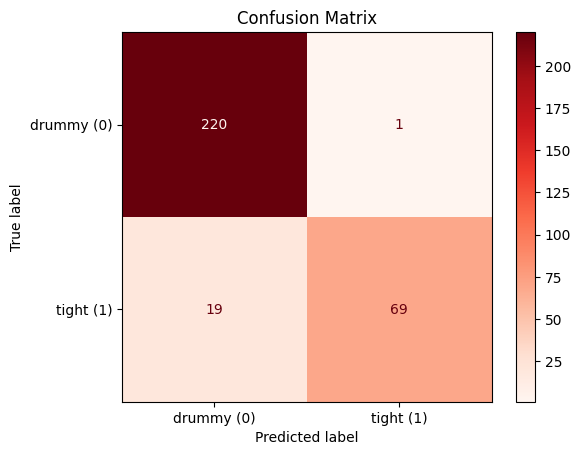

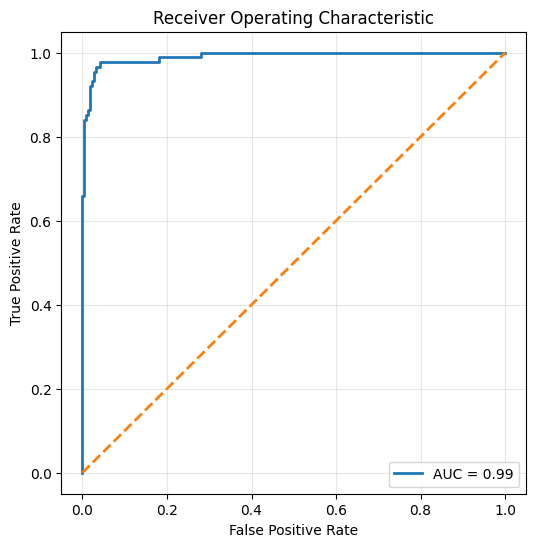


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

  drummy (0)       0.92      1.00      0.96       221
   tight (1)       0.99      0.78      0.87        88

    accuracy                           0.94       309
   macro avg       0.95      0.89      0.91       309
weighted avg       0.94      0.94      0.93       309



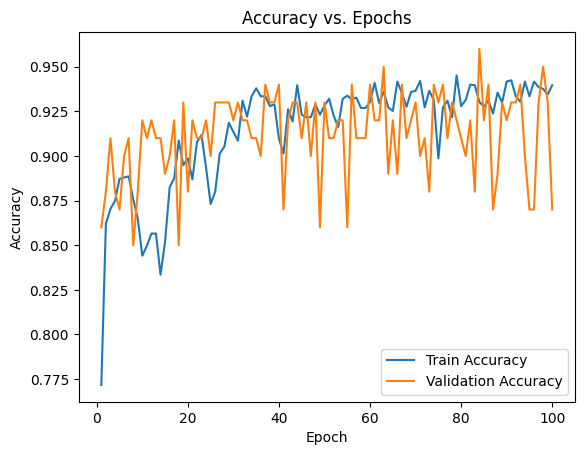

In [5]:
torch.manual_seed(42)
np.random.seed(42)


train_idx = list(range(0, 2900))
val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(P1_raw, train_idx)
val_data = torch.utils.data.Subset(P1_raw, val_idx)
test_data = torch.utils.data.Subset(P1_raw, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 100

print(train_loader.dataset[0][0].shape)

model = models.MFCC_MLP_p1()

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    history = loops.train(model=model, model_path="./final_model_paths/mfcc_p1_val.pth", train_loader=train_loader,val=True, val_loader=val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/mfcc_p1_val.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


#### Test Routine

torch.Size([36000])
[INFO] Testing the model
Test accuracy (threshold=0.50): 0.9417


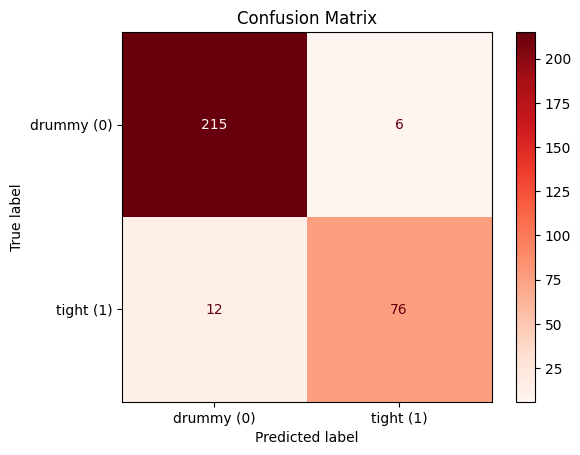

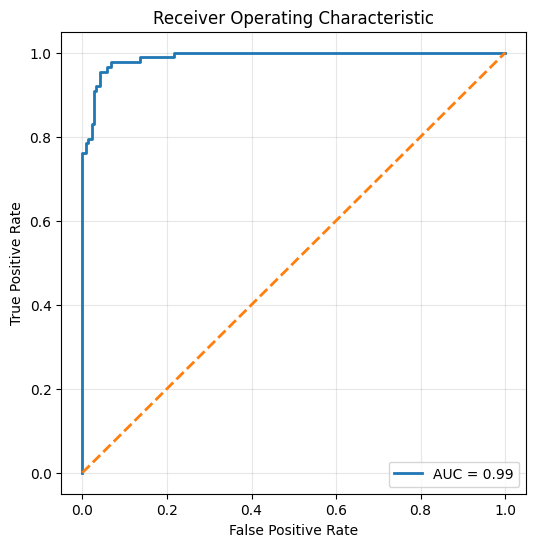


Classification Report (threshold = 0.50):

              precision    recall  f1-score   support

  drummy (0)       0.95      0.97      0.96       221
   tight (1)       0.93      0.86      0.89        88

    accuracy                           0.94       309
   macro avg       0.94      0.92      0.93       309
weighted avg       0.94      0.94      0.94       309



,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds
0,mlp2_ev90_h256_P1_RETRAIN,MLP (2-layer),90,256,0.853474,0.915736,"[0.0, 0.0, 0.0, 0.004514672686230248, 0.004514...","[0.0, 0.0045662100456621, 0.0273972602739726, ...","[inf, 0.9966568, 0.9921319, 0.98960984, 0.9395..."
1,svm_rbf_pca_ev90,SVM (RBF),90,—,0.826284,0.881346,"[0.0, 0.0, 0.002257336343115124, 0.00225733634...","[0.0, 0.0045662100456621, 0.0045662100456621, ...","[inf, 0.9787043639894185, 0.9647695390493778, ..."
2,resnet_mlp_p1,ResNet_MLP_P1,NaN,NaN,0.970874,0.996812,"[0.0, 0.0, 0.0, 0.004524886877828055, 0.004524...","[0.0, 0.011363636363636364, 0.875, 0.875, 0.92...","[inf, 0.99922836, 0.88022715, 0.84186965, 0.69..."
3,mfcc_mlp_p1,MFCC_MLP_P1,NaN,NaN,0.941748,0.989510,"[0.0, 0.0, 0.0, 0.00904977375565611, 0.0090497...","[0.0, 0.011363636363636364, 0.7613636363636364...","[inf, 0.98811847, 0.6602692, 0.62575316, 0.595..."


In [19]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
test_idx = list(range(3000, 3309))

train_data = torch.utils.data.Subset(P1_raw, train_idx)
test_data = torch.utils.data.Subset(P1_raw, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 50

print(train_loader.dataset[0][0].shape)

model = models.MFCC_MLP_p1()
model_name = "mfcc_mlp_p1"

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    loops.train(model=model, model_path="./final_model_paths/end_mfcc_p1_test.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

test_results = loops.test(model=model, model_path="./final_model_paths/end_mfcc_p1_test.pth", test_loader=test_loader, report=True, score=True)

acc = test_results["accuracy"]
roc_auc = test_results["roc_auc"]
fpr = test_results["fpr"]
tpr = test_results["tpr"]
roc_thresholds = test_results["roc_thresholds"]

new_row = pd.DataFrame([{
    "model_name": model_name,
    "model": "MFCC_MLP_P1",
    "ev_pct": np.nan,
    "hidden": np.nan,
    "accuracy": acc,
    "roc_auc": roc_auc,
    "fpr": np.array(fpr),
    "tpr": np.array(tpr),
    "roc_thresholds": np.array(roc_thresholds),
}])

if "roc_df" not in globals():
    roc_df = pd.DataFrame(columns=[
        "model_name",
        "model",
        "ev_pct",
        "hidden",
        "accuracy",
        "roc_auc",
        "fpr",
        "tpr",
        "roc_thresholds",
    ])

roc_df = roc_df[roc_df["model_name"] != model_name]
roc_df = pd.concat([roc_df, new_row], ignore_index=True)

display(roc_df)

In [22]:
roc_df.loc[0, "model"] = "PCA(90%) + MLP (2-layer)"
roc_df.loc[1, "model"] = "PCA(90%) + SVM (RBF)"

display(roc_df)

,model_name,model,ev_pct,hidden,accuracy,roc_auc,fpr,tpr,roc_thresholds
0,mlp2_ev90_h256_P1_RETRAIN,PCA(90%) + MLP (2-layer),90,256,0.853474,0.915736,"[0.0, 0.0, 0.0, 0.004514672686230248, 0.004514...","[0.0, 0.0045662100456621, 0.0273972602739726, ...","[inf, 0.9966568, 0.9921319, 0.98960984, 0.9395..."
1,svm_rbf_pca_ev90,PCA(90%) + SVM (RBF),90,—,0.826284,0.881346,"[0.0, 0.0, 0.002257336343115124, 0.00225733634...","[0.0, 0.0045662100456621, 0.0045662100456621, ...","[inf, 0.9787043639894185, 0.9647695390493778, ..."
2,resnet_mlp_p1,ResNet_MLP_P1,NaN,NaN,0.970874,0.996812,"[0.0, 0.0, 0.0, 0.004524886877828055, 0.004524...","[0.0, 0.011363636363636364, 0.875, 0.875, 0.92...","[inf, 0.99922836, 0.88022715, 0.84186965, 0.69..."
3,mfcc_mlp_p1,MFCC_MLP_P1,NaN,NaN,0.941748,0.989510,"[0.0, 0.0, 0.0, 0.00904977375565611, 0.0090497...","[0.0, 0.011363636363636364, 0.7613636363636364...","[inf, 0.98811847, 0.6602692, 0.62575316, 0.595..."


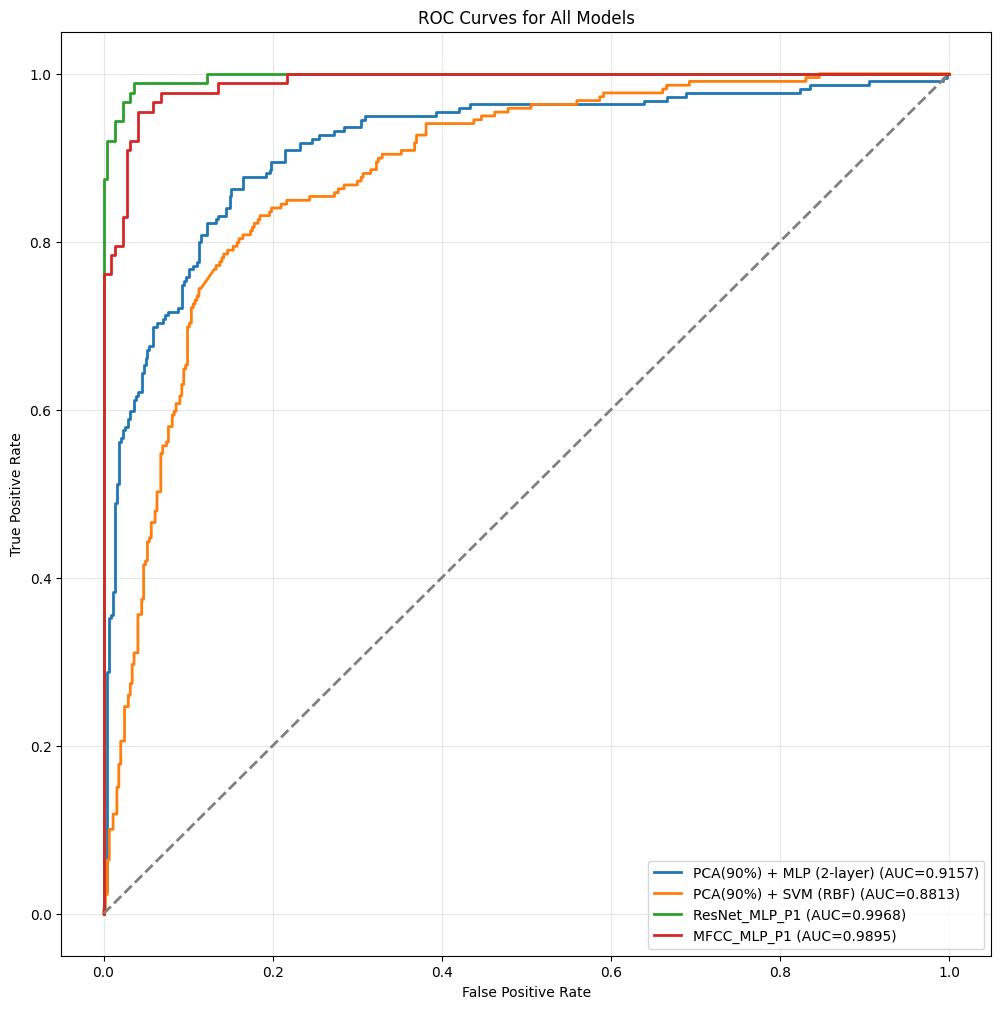

In [23]:
# generate ROC curve for all models in roc_df
plt.figure(figsize=(12, 12))
for idx, row in roc_df.iterrows():
    plt.plot(row["fpr"], row["tpr"], lw=2, label=f"{row['model']} (AUC={row['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()